In [1]:
from pathlib import Path
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

from ewatercycle.models import Wflow
from ewatercycle.parameter_sets import available_parameter_sets
from ewatercycle.forcing import sources

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", None)

print("Imports geladen")

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


Imports geladen


In [2]:
project_dir = Path("/home/niels/BEP-Niels")

temp_dir = project_dir / "temp_runs"
results_dir = project_dir / "results"
parameter_results_dir = results_dir / "Parameter_Gevoeligheid"

parameter_results_dir.mkdir(exist_ok=True)

model_start = "1986-01-01T00:00:00Z"
model_end = "1996-01-01T00:00:00Z"

calibration_start = "1987-01-01"
calibration_end = "1995-12-31"

print("Projectmap bestaat:", project_dir.exists())
print("Parameter results map:", parameter_results_dir)

Projectmap bestaat: True
Parameter results map: /home/niels/BEP-Niels/results/Parameter_Gevoeligheid


In [3]:
forcing_file = temp_dir / "forcing_basisrun_1987_1995" / "work" / "diagnostic" / "script" / "wflow_ERA5_Rhine_1986_1995.nc"

print("Forcingbestand bestaat:", forcing_file.exists())
print(forcing_file)

Forcingbestand bestaat: True
/home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1995/work/diagnostic/script/wflow_ERA5_Rhine_1986_1995.nc


In [4]:
WflowForcing = sources["WflowForcing"]

forcing = WflowForcing(
    start_time=model_start,
    end_time=model_end,
    directory=str(forcing_file.parent),
    netcdfinput=forcing_file.name,
    Precipitation="/pr",
    EvapoTranspiration="/pet",
    Temperature="/tas",
    Inflow=None,
)

print("Forcing gekoppeld")

Forcing gekoppeld


In [5]:
parameter_sets = available_parameter_sets(target_model="wflow")

parameter_set = parameter_sets["wflow_rhine_sbm_nc"]
parameter_set.config = Path(parameter_set.directory) / "wflow_sbm_NC.ini"

lat_lobith = 51.849999998
lon_lobith = 6.0999999998

print("Parameter set:", parameter_set.directory)
print("Config bestaat:", parameter_set.config.exists())
print("Lobith:", lat_lobith, lon_lobith)

Parameter set: /data/shared/parameter-sets/wflow_rhine_sbm_nc
Config bestaat: True
Lobith: 51.849999998 6.0999999998


In [6]:
grdc_file = project_dir / "Data Lobith" / "data grdc" / "6435060_Q_Day.Cmd.txt"

grdc = pd.read_csv(
    grdc_file,
    sep=";",
    comment="#",
    skipinitialspace=True,
    na_values=-999.000,
    encoding="latin1"
)

grdc.columns = grdc.columns.str.strip()

grdc = grdc.rename(columns={
    "YYYY-MM-DD": "date",
    "Value": "Q_grdc_m3s"
})

grdc["date"] = pd.to_datetime(grdc["date"])
grdc["Q_grdc_m3s"] = pd.to_numeric(grdc["Q_grdc_m3s"])

grdc = grdc.dropna(subset=["Q_grdc_m3s"])

grdc_calibration = grdc[
    (grdc["date"] >= calibration_start) &
    (grdc["date"] <= calibration_end)
].copy()

grdc_calibration = grdc_calibration[["date", "Q_grdc_m3s"]]

print("Aantal GRDC dagen:", len(grdc_calibration))
print(grdc_calibration["date"].min(), "t/m", grdc_calibration["date"].max())

Aantal GRDC dagen: 3287
1987-01-01 00:00:00 t/m 1995-12-31 00:00:00


In [7]:
def scores(comparison):
    obs = comparison["Q_grdc_m3s"]
    sim = comparison["Q_model_m3s"]

    bias = (sim - obs).mean()
    rmse = np.sqrt(((sim - obs) ** 2).mean())

    log_obs = np.log(obs)
    log_sim = np.log(sim)

    log_nse = 1 - ((log_sim - log_obs) ** 2).sum() / ((log_obs - log_obs.mean()) ** 2).sum()

    low_1600 = obs < 1600

    return {
        "bias": bias,
        "rmse": rmse,
        "log_nse": log_nse,

        "bias_low_1600": (sim[low_1600] - obs[low_1600]).mean(),
        "mae_low_1600": abs(sim[low_1600] - obs[low_1600]).mean(),

        "grdc_days_below_1600": (obs < 1600).sum(),
        "model_days_below_1600": (sim < 1600).sum(),
        "diff_days_below_1600": (sim < 1600).sum() - (obs < 1600).sum(),

        "grdc_days_below_1020": (obs < 1020).sum(),
        "model_days_below_1020": (sim < 1020).sum(),
        "diff_days_below_1020": (sim < 1020).sum() - (obs < 1020).sum(),

        "grdc_p10": obs.quantile(0.10),
        "model_p10": sim.quantile(0.10),
        "diff_p10": sim.quantile(0.10) - obs.quantile(0.10),

        "grdc_p17": obs.quantile(0.17),
        "model_p17": sim.quantile(0.17),
        "diff_p17": sim.quantile(0.17) - obs.quantile(0.17),
    }

In [8]:
basis_file = parameter_results_dir / "basisrun_full_1987_1995_lobith_daily.csv"

if not basis_file.exists():
    basis_file = results_dir / "basisrun_full_1987_1995_lobith_daily.csv"

print("Basisbestand bestaat:", basis_file.exists())
print(basis_file)

model_basis_full = pd.read_csv(basis_file)
model_basis_full["date"] = pd.to_datetime(model_basis_full["date"])

comparison_basis_full = pd.merge(
    grdc_calibration,
    model_basis_full,
    on="date",
    how="inner"
)

basis_scores_full = scores(comparison_basis_full)

pd.DataFrame([basis_scores_full], index=["basis_full"]).round(2)

Basisbestand bestaat: True
/home/niels/BEP-Niels/results/basisrun_full_1987_1995_lobith_daily.csv


,bias,rmse,log_nse,bias_low_1600,mae_low_1600,grdc_days_below_1600,model_days_below_1600,diff_days_below_1600,grdc_days_below_1020,model_days_below_1020,diff_days_below_1020,grdc_p10,model_p10,diff_p10,grdc_p17,model_p17,diff_p17
basis_full,710.1,1998.63,-0.94,-116.22,575.02,1150,1291,141,125,812,687,1187.2,572.26,-614.94,1310.62,779.24,-531.38


In [9]:
def multiply_tbl(tbl_file, factor):
    lines = Path(tbl_file).read_text().splitlines()
    new_lines = []

    for line in lines:
        parts = line.split()

        try:
            value = float(parts[-1])
            parts[-1] = str(value * factor)
            new_lines.append(" ".join(parts))
        except:
            new_lines.append(line)

    Path(tbl_file).write_text("\n".join(new_lines))

In [10]:
run_name = "calib1_NRiver_x1p25_N_x1p25"
run_dir = temp_dir / run_name

parameters = {
    "N_River.tbl": 1.25,
    "N.tbl": 1.25,
}

print("Run:", run_name)
print("Runmap:", run_dir)

for parameter_name, factor in parameters.items():
    print(parameter_name, "x", factor)

Run: calib1_NRiver_x1p25_N_x1p25
Runmap: /home/niels/BEP-Niels/temp_runs/calib1_NRiver_x1p25_N_x1p25
N_River.tbl x 1.25
N.tbl x 1.25


In [11]:
if run_dir.exists():
    shutil.rmtree(run_dir)

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing
)

cfg_file, cfg_dir = model.setup(cfg_dir=str(run_dir))
cfg_dir = Path(cfg_dir)

for parameter_name, factor in parameters.items():
    tbl_files = list(cfg_dir.rglob(parameter_name))

    print("\nParameter:", parameter_name)
    print("Aantal gevonden bestanden:", len(tbl_files))

    for tbl_file in tbl_files:
        print("Aanpassen:", tbl_file)
        multiply_tbl(tbl_file, factor)


Parameter: N_River.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib1_NRiver_x1p25_N_x1p25/intbl/N_River.tbl

Parameter: N.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib1_NRiver_x1p25_N_x1p25/intbl/N.tbl


In [12]:
model.initialize(cfg_file)

dates = []
q_values = []

step = 0

while model.time < model.end_time:
    model.update()

    q = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat_lobith],
        lon=[lon_lobith]
    )[0]

    dates.append(model.time_as_datetime)
    q_values.append(float(q))

    step += 1

    if step % 365 == 0:
        print(step, model.time_as_datetime, round(float(q), 1))

model.finalize()

print("Run klaar")

365 1986-12-31 00:00:00 11326.5
730 1987-12-31 00:00:00 2693.1
1095 1988-12-30 00:00:00 4531.5
1460 1989-12-30 00:00:00 5416.8
1825 1990-12-30 00:00:00 5827.5
2190 1991-12-30 00:00:00 8372.5
2555 1992-12-29 00:00:00 2140.3
2920 1993-12-29 00:00:00 11947.2
3285 1994-12-29 00:00:00 4300.7
3650 1995-12-29 00:00:00 9905.5
Run klaar


In [13]:
model_calib1 = pd.DataFrame({
    "date": pd.to_datetime(dates, utc=True),
    "Q_model_m3s": q_values
})

model_calib1["date"] = model_calib1["date"].dt.tz_convert(None).dt.floor("D")

model_calib1 = model_calib1[
    (model_calib1["date"] >= calibration_start) &
    (model_calib1["date"] <= calibration_end)
].copy()

output_file = parameter_results_dir / f"{run_name}_lobith_daily.csv"

model_calib1.to_csv(output_file, index=False)

print("Aantal dagen:", len(model_calib1))
print("Opgeslagen als:", output_file)

Aantal dagen: 3287
Opgeslagen als: /home/niels/BEP-Niels/results/Parameter_Gevoeligheid/calib1_NRiver_x1p25_N_x1p25_lobith_daily.csv


In [14]:
comparison_calib1 = pd.merge(
    grdc_calibration,
    model_calib1,
    on="date",
    how="inner"
)

scores_calib1 = scores(comparison_calib1)

pd.DataFrame(
    [basis_scores_full, scores_calib1],
    index=["basis_full", run_name]
).round(2)

,bias,rmse,log_nse,bias_low_1600,mae_low_1600,grdc_days_below_1600,model_days_below_1600,diff_days_below_1600,grdc_days_below_1020,model_days_below_1020,diff_days_below_1020,grdc_p10,model_p10,diff_p10,grdc_p17,model_p17,diff_p17
basis_full,710.10,1998.63,-0.94,-116.22,575.02,1150,1291,141,125,812,687,1187.2,572.26,-614.94,1310.62,779.24,-531.38
calib1_NRiver_x1p25_N_x1p25,709.39,1874.04,-0.69,-76.24,540.51,1150,1247,97,125,762,637,1187.2,629.46,-557.74,1310.62,835.37,-475.25


In [15]:
check = pd.merge(
    model_basis_full,
    model_calib1,
    on="date",
    suffixes=("_basis", "_calib1")
)

check["verschil"] = check["Q_model_m3s_calib1"] - check["Q_model_m3s_basis"]

print("Max verschil:", check["verschil"].abs().max())
print("Gemiddeld verschil:", check["verschil"].mean())

Max verschil: 4136.8984375
Gemiddeld verschil: -0.7056591798731865


In [16]:
pet_factor = 0.95

forcing_pet_dir = temp_dir / "forcing_pet_x0p95_1987_1995"
forcing_pet_dir.mkdir(exist_ok=True)

forcing_pet_file = forcing_pet_dir / "wflow_ERA5_Rhine_1986_1995_pet_x0p95.nc"

if forcing_pet_file.exists():
    print("PET x0.95 forcing bestaat al:")
    print(forcing_pet_file)

else:
    ds = xr.open_dataset(forcing_file)
    ds_new = ds.copy()

    ds_new["pet"] = ds_new["pet"] * pet_factor

    ds_new.to_netcdf(forcing_pet_file)

    ds.close()
    ds_new.close()

    print("PET x0.95 forcing opgeslagen:")
    print(forcing_pet_file)

PET x0.95 forcing bestaat al:
/home/niels/BEP-Niels/temp_runs/forcing_pet_x0p95_1987_1995/wflow_ERA5_Rhine_1986_1995_pet_x0p95.nc


In [17]:
WflowForcing = sources["WflowForcing"]

forcing_pet_095 = WflowForcing(
    start_time=model_start,
    end_time=model_end,
    directory=str(forcing_pet_file.parent),
    netcdfinput=forcing_pet_file.name,
    Precipitation="/pr",
    EvapoTranspiration="/pet",
    Temperature="/tas",
    Inflow=None,
)

print("PET x0.95 forcing gekoppeld")

PET x0.95 forcing gekoppeld


In [18]:
run_name = "calib2_PET_x0p95_NRiver_x1p25"
run_dir = temp_dir / run_name

parameter_name = "N_River.tbl"
factor = 1.25

print("Run:", run_name)
print("Runmap:", run_dir)
print("Parameter:", parameter_name, "x", factor)

Run: calib2_PET_x0p95_NRiver_x1p25
Runmap: /home/niels/BEP-Niels/temp_runs/calib2_PET_x0p95_NRiver_x1p25
Parameter: N_River.tbl x 1.25


In [19]:
if run_dir.exists():
    shutil.rmtree(run_dir)

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing_pet_095
)

cfg_file, cfg_dir = model.setup(cfg_dir=str(run_dir))
cfg_dir = Path(cfg_dir)

tbl_files = list(cfg_dir.rglob(parameter_name))

print("Aantal gevonden parameterbestanden:", len(tbl_files))

for tbl_file in tbl_files:
    print("Aanpassen:", tbl_file)
    multiply_tbl(tbl_file, factor)

Aantal gevonden parameterbestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib2_PET_x0p95_NRiver_x1p25/intbl/N_River.tbl


In [20]:
model.initialize(cfg_file)

dates = []
q_values = []

step = 0

while model.time < model.end_time:
    model.update()

    q = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat_lobith],
        lon=[lon_lobith]
    )[0]

    dates.append(model.time_as_datetime)
    q_values.append(float(q))

    step += 1

    if step % 365 == 0:
        print(step, model.time_as_datetime, round(float(q), 1))

model.finalize()

print("Run klaar")

365 1986-12-31 00:00:00 11551.0
730 1987-12-31 00:00:00 2609.7
1095 1988-12-30 00:00:00 4497.0
1460 1989-12-30 00:00:00 5495.2
1825 1990-12-30 00:00:00 6263.5
2190 1991-12-30 00:00:00 8403.3
2555 1992-12-29 00:00:00 2098.1
2920 1993-12-29 00:00:00 11612.8
3285 1994-12-29 00:00:00 4737.3
3650 1995-12-29 00:00:00 10443.0
Run klaar


In [21]:
model_calib2 = pd.DataFrame({
    "date": pd.to_datetime(dates, utc=True),
    "Q_model_m3s": q_values
})

model_calib2["date"] = model_calib2["date"].dt.tz_convert(None).dt.floor("D")

model_calib2 = model_calib2[
    (model_calib2["date"] >= calibration_start) &
    (model_calib2["date"] <= calibration_end)
].copy()

output_file = parameter_results_dir / f"{run_name}_lobith_daily.csv"

model_calib2.to_csv(output_file, index=False)

print("Aantal dagen:", len(model_calib2))
print("Opgeslagen als:", output_file)

Aantal dagen: 3287
Opgeslagen als: /home/niels/BEP-Niels/results/Parameter_Gevoeligheid/calib2_PET_x0p95_NRiver_x1p25_lobith_daily.csv


In [22]:
comparison_calib2 = pd.merge(
    grdc_calibration,
    model_calib2,
    on="date",
    how="inner"
)

scores_calib2 = scores(comparison_calib2)

pd.DataFrame(
    [basis_scores_full, scores_calib2],
    index=["basis_full", run_name]
).round(2)

,bias,rmse,log_nse,bias_low_1600,mae_low_1600,grdc_days_below_1600,model_days_below_1600,diff_days_below_1600,grdc_days_below_1020,model_days_below_1020,diff_days_below_1020,grdc_p10,model_p10,diff_p10,grdc_p17,model_p17,diff_p17
basis_full,710.10,1998.63,-0.94,-116.22,575.02,1150,1291,141,125,812,687,1187.2,572.26,-614.94,1310.62,779.24,-531.38
calib2_PET_x0p95_NRiver_x1p25,847.56,2037.71,-0.78,-9.33,574.82,1150,1191,41,125,707,582,1187.2,642.60,-544.60,1310.62,862.45,-448.17


In [23]:
pd.DataFrame(
    [basis_scores_full, scores_calib1, scores_calib2],
    index=[
        "basis_full",
        "calib1_NRiver_x1p25_N_x1p25",
        "calib2_PET_x0p95_NRiver_x1p25"
    ]
).round(2)

,bias,rmse,log_nse,bias_low_1600,mae_low_1600,grdc_days_below_1600,model_days_below_1600,diff_days_below_1600,grdc_days_below_1020,model_days_below_1020,diff_days_below_1020,grdc_p10,model_p10,diff_p10,grdc_p17,model_p17,diff_p17
basis_full,710.10,1998.63,-0.94,-116.22,575.02,1150,1291,141,125,812,687,1187.2,572.26,-614.94,1310.62,779.24,-531.38
calib1_NRiver_x1p25_N_x1p25,709.39,1874.04,-0.69,-76.24,540.51,1150,1247,97,125,762,637,1187.2,629.46,-557.74,1310.62,835.37,-475.25
calib2_PET_x0p95_NRiver_x1p25,847.56,2037.71,-0.78,-9.33,574.82,1150,1191,41,125,707,582,1187.2,642.60,-544.60,1310.62,862.45,-448.17


In [24]:
run_name = "calib3_PET_x0p95_NRiver_x1p25_N_x1p25"
run_dir = temp_dir / run_name

parameters = {
    "N_River.tbl": 1.25,
    "N.tbl": 1.25,
}

print("Run:", run_name)
print("Runmap:", run_dir)

for parameter_name, factor in parameters.items():
    print(parameter_name, "x", factor)

Run: calib3_PET_x0p95_NRiver_x1p25_N_x1p25
Runmap: /home/niels/BEP-Niels/temp_runs/calib3_PET_x0p95_NRiver_x1p25_N_x1p25
N_River.tbl x 1.25
N.tbl x 1.25


In [25]:
if run_dir.exists():
    shutil.rmtree(run_dir)

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing_pet_095
)

cfg_file, cfg_dir = model.setup(cfg_dir=str(run_dir))
cfg_dir = Path(cfg_dir)

for parameter_name, factor in parameters.items():
    tbl_files = list(cfg_dir.rglob(parameter_name))

    print("\nParameter:", parameter_name)
    print("Aantal gevonden bestanden:", len(tbl_files))

    for tbl_file in tbl_files:
        print("Aanpassen:", tbl_file)
        multiply_tbl(tbl_file, factor)


Parameter: N_River.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib3_PET_x0p95_NRiver_x1p25_N_x1p25/intbl/N_River.tbl

Parameter: N.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib3_PET_x0p95_NRiver_x1p25_N_x1p25/intbl/N.tbl


In [26]:
model.initialize(cfg_file)

dates = []
q_values = []

step = 0

while model.time < model.end_time:
    model.update()

    q = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat_lobith],
        lon=[lon_lobith]
    )[0]

    dates.append(model.time_as_datetime)
    q_values.append(float(q))

    step += 1

    if step % 365 == 0:
        print(step, model.time_as_datetime, round(float(q), 1))

model.finalize()

print("Run klaar")

365 1986-12-31 00:00:00 11388.4
730 1987-12-31 00:00:00 2735.2
1095 1988-12-30 00:00:00 4636.1
1460 1989-12-30 00:00:00 5716.3
1825 1990-12-30 00:00:00 6074.7
2190 1991-12-30 00:00:00 8634.3
2555 1992-12-29 00:00:00 2177.3
2920 1993-12-29 00:00:00 12003.0
3285 1994-12-29 00:00:00 4477.1
3650 1995-12-29 00:00:00 10245.3
Run klaar


In [27]:
model_calib3 = pd.DataFrame({
    "date": pd.to_datetime(dates, utc=True),
    "Q_model_m3s": q_values
})

model_calib3["date"] = model_calib3["date"].dt.tz_convert(None).dt.floor("D")

model_calib3 = model_calib3[
    (model_calib3["date"] >= calibration_start) &
    (model_calib3["date"] <= calibration_end)
].copy()

output_file = parameter_results_dir / f"{run_name}_lobith_daily.csv"

model_calib3.to_csv(output_file, index=False)

print("Aantal dagen:", len(model_calib3))
print("Opgeslagen als:", output_file)

Aantal dagen: 3287
Opgeslagen als: /home/niels/BEP-Niels/results/Parameter_Gevoeligheid/calib3_PET_x0p95_NRiver_x1p25_N_x1p25_lobith_daily.csv


In [28]:
comparison_calib3 = pd.merge(
    grdc_calibration,
    model_calib3,
    on="date",
    how="inner"
)

scores_calib3 = scores(comparison_calib3)

pd.DataFrame(
    [basis_scores_full, scores_calib3],
    index=["basis_full", run_name]
).round(2)

,bias,rmse,log_nse,bias_low_1600,mae_low_1600,grdc_days_below_1600,model_days_below_1600,diff_days_below_1600,grdc_days_below_1020,model_days_below_1020,diff_days_below_1020,grdc_p10,model_p10,diff_p10,grdc_p17,model_p17,diff_p17
basis_full,710.10,1998.63,-0.94,-116.22,575.02,1150,1291,141,125,812,687,1187.2,572.26,-614.94,1310.62,779.24,-531.38
calib3_PET_x0p95_NRiver_x1p25_N_x1p25,847.14,1997.49,-0.69,5.00,563.47,1150,1182,32,125,690,565,1187.2,674.99,-512.21,1310.62,889.36,-421.26


In [29]:
pd.DataFrame(
    [basis_scores_full, scores_calib1, scores_calib2, scores_calib3],
    index=[
        "basis_full",
        "calib1_NRiver_x1p25_N_x1p25",
        "calib2_PET_x0p95_NRiver_x1p25",
        "calib3_PET_x0p95_NRiver_x1p25_N_x1p25"
    ]
).round(2)

,bias,rmse,log_nse,bias_low_1600,mae_low_1600,grdc_days_below_1600,model_days_below_1600,diff_days_below_1600,grdc_days_below_1020,model_days_below_1020,diff_days_below_1020,grdc_p10,model_p10,diff_p10,grdc_p17,model_p17,diff_p17
basis_full,710.10,1998.63,-0.94,-116.22,575.02,1150,1291,141,125,812,687,1187.2,572.26,-614.94,1310.62,779.24,-531.38
calib1_NRiver_x1p25_N_x1p25,709.39,1874.04,-0.69,-76.24,540.51,1150,1247,97,125,762,637,1187.2,629.46,-557.74,1310.62,835.37,-475.25
calib2_PET_x0p95_NRiver_x1p25,847.56,2037.71,-0.78,-9.33,574.82,1150,1191,41,125,707,582,1187.2,642.60,-544.60,1310.62,862.45,-448.17
calib3_PET_x0p95_NRiver_x1p25_N_x1p25,847.14,1997.49,-0.69,5.00,563.47,1150,1182,32,125,690,565,1187.2,674.99,-512.21,1310.62,889.36,-421.26


In [30]:
plot_data = comparison_basis_full[["date", "Q_grdc_m3s", "Q_model_m3s"]].copy()
plot_data = plot_data.rename(columns={"Q_model_m3s": "Q_basis_m3s"})

calib3_plot = model_calib3[["date", "Q_model_m3s"]].copy()
calib3_plot = calib3_plot.rename(columns={"Q_model_m3s": "Q_calib3_m3s"})

plot_data = pd.merge(
    plot_data,
    calib3_plot,
    on="date",
    how="inner"
)

plot_data.head()

,date,Q_grdc_m3s,Q_basis_m3s,Q_calib3_m3s
0,1987-01-01,4865.0,13869.678711,12996.366211
1,1987-01-02,5756.0,15741.568359,14758.045898
2,1987-01-03,6160.0,16061.675781,15536.477539
3,1987-01-04,6973.0,15124.300781,15181.709961
4,1987-01-05,7579.0,13978.630859,14339.648438


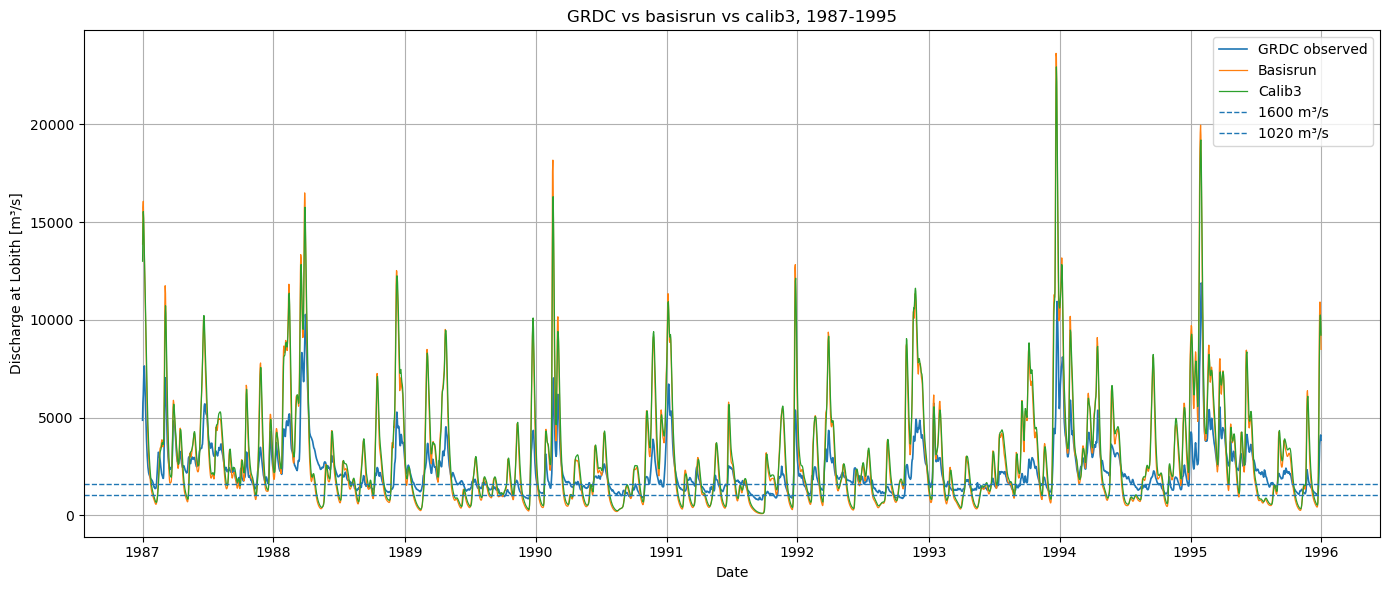

In [31]:
plt.figure(figsize=(14, 6))

plt.plot(plot_data["date"], plot_data["Q_grdc_m3s"], label="GRDC observed", linewidth=1.2)
plt.plot(plot_data["date"], plot_data["Q_basis_m3s"], label="Basisrun", linewidth=0.9)
plt.plot(plot_data["date"], plot_data["Q_calib3_m3s"], label="Calib3", linewidth=0.9)

plt.axhline(1600, linestyle="--", linewidth=1, label="1600 m³/s")
plt.axhline(1020, linestyle="--", linewidth=1, label="1020 m³/s")

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("GRDC vs basisrun vs calib3, 1987-1995")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

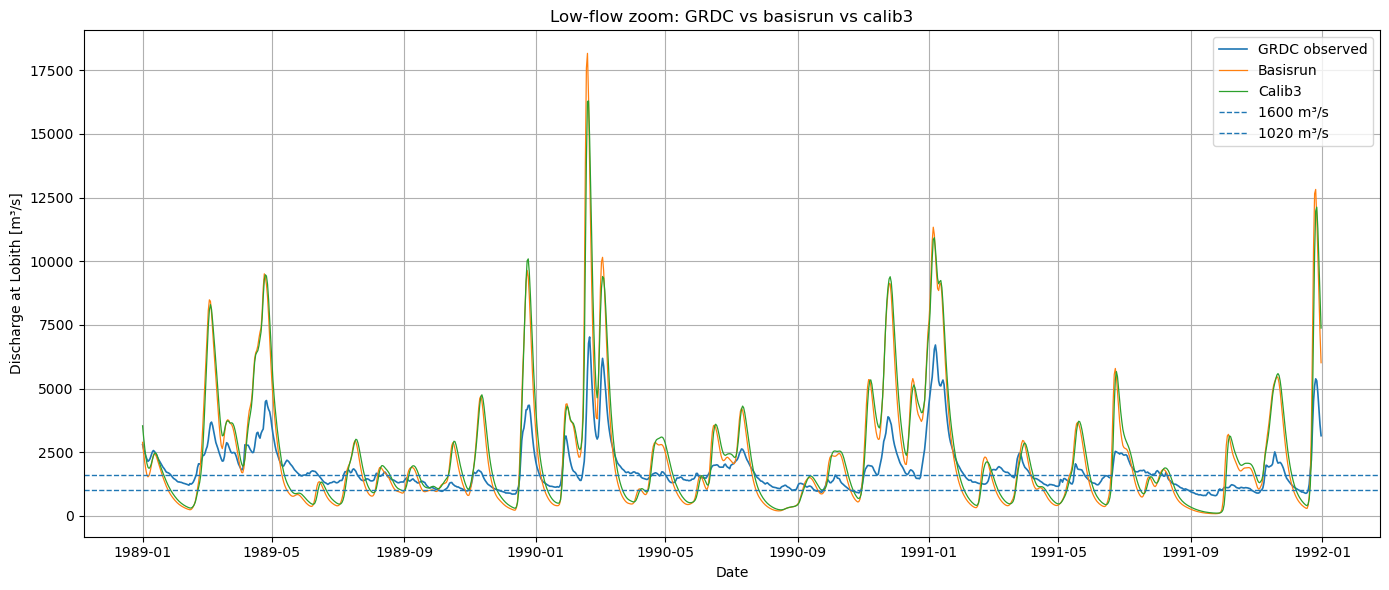

In [32]:
plot_start = "1989-01-01"
plot_end = "1991-12-31"

zoom = plot_data[
    (plot_data["date"] >= plot_start) &
    (plot_data["date"] <= plot_end)
]

plt.figure(figsize=(14, 6))

plt.plot(zoom["date"], zoom["Q_grdc_m3s"], label="GRDC observed", linewidth=1.2)
plt.plot(zoom["date"], zoom["Q_basis_m3s"], label="Basisrun", linewidth=0.9)
plt.plot(zoom["date"], zoom["Q_calib3_m3s"], label="Calib3", linewidth=0.9)

plt.axhline(1600, linestyle="--", linewidth=1, label="1600 m³/s")
plt.axhline(1020, linestyle="--", linewidth=1, label="1020 m³/s")

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("Low-flow zoom: GRDC vs basisrun vs calib3")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

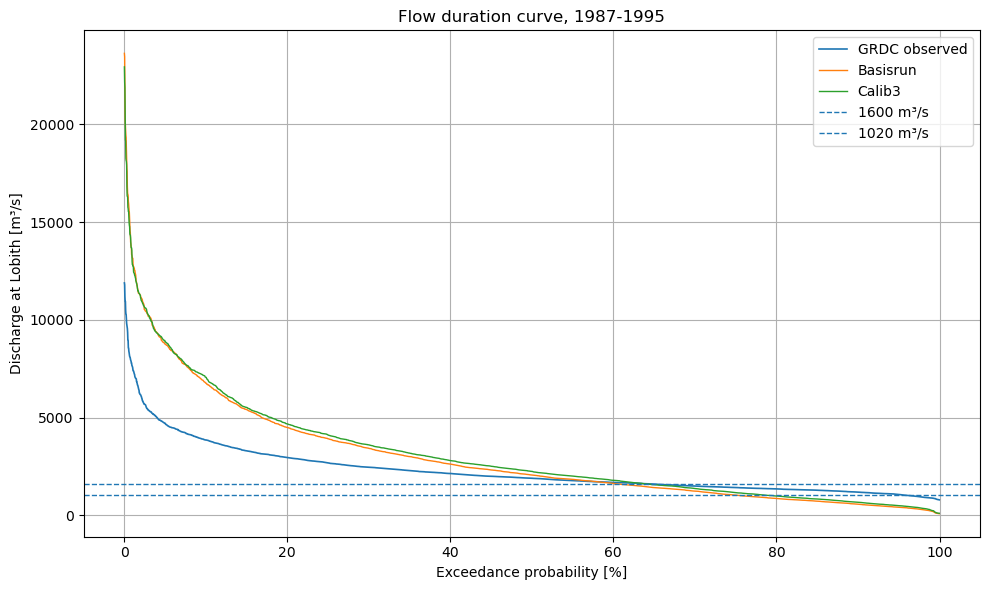

In [33]:
fdc = pd.DataFrame()

fdc["GRDC"] = np.sort(plot_data["Q_grdc_m3s"].values)[::-1]
fdc["Basisrun"] = np.sort(plot_data["Q_basis_m3s"].values)[::-1]
fdc["Calib3"] = np.sort(plot_data["Q_calib3_m3s"].values)[::-1]

fdc["exceedance"] = np.arange(1, len(fdc) + 1) / (len(fdc) + 1) * 100

plt.figure(figsize=(10, 6))

plt.plot(fdc["exceedance"], fdc["GRDC"], label="GRDC observed", linewidth=1.2)
plt.plot(fdc["exceedance"], fdc["Basisrun"], label="Basisrun", linewidth=1.0)
plt.plot(fdc["exceedance"], fdc["Calib3"], label="Calib3", linewidth=1.0)

plt.axhline(1600, linestyle="--", linewidth=1, label="1600 m³/s")
plt.axhline(1020, linestyle="--", linewidth=1, label="1020 m³/s")

plt.xlabel("Exceedance probability [%]")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("Flow duration curve, 1987-1995")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

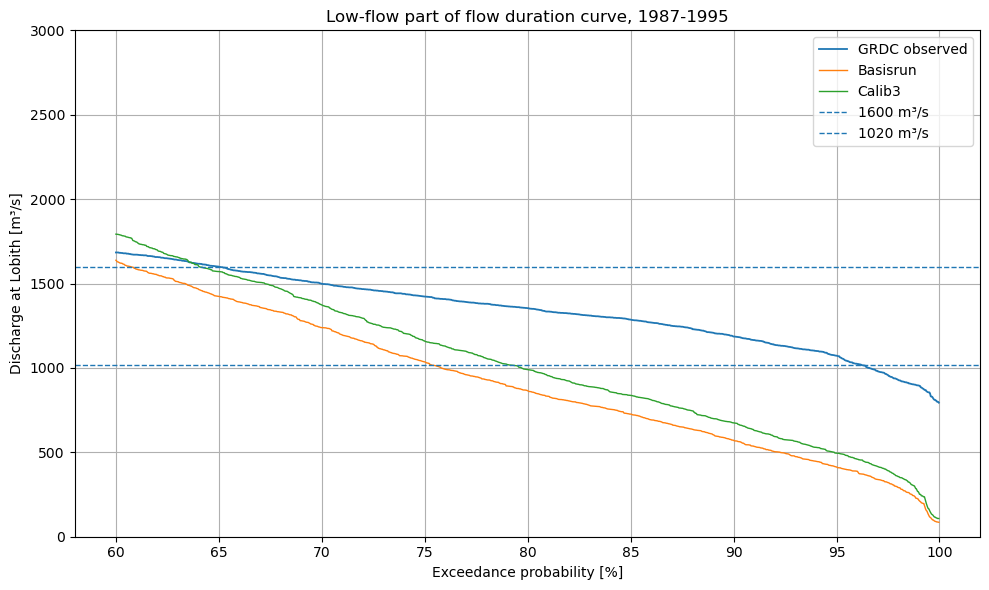

In [34]:
fdc_zoom = fdc[fdc["exceedance"] >= 60]

plt.figure(figsize=(10, 6))

plt.plot(fdc_zoom["exceedance"], fdc_zoom["GRDC"], label="GRDC observed", linewidth=1.3)
plt.plot(fdc_zoom["exceedance"], fdc_zoom["Basisrun"], label="Basisrun", linewidth=1.0)
plt.plot(fdc_zoom["exceedance"], fdc_zoom["Calib3"], label="Calib3", linewidth=1.0)

plt.axhline(1600, linestyle="--", linewidth=1, label="1600 m³/s")
plt.axhline(1020, linestyle="--", linewidth=1, label="1020 m³/s")

plt.xlabel("Exceedance probability [%]")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("Low-flow part of flow duration curve, 1987-1995")
plt.ylim(0, 3000)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
run_name = "calib4_PET_x0p95_NRiver_x1p50_N_x1p25"
run_dir = temp_dir / run_name

parameters = {
    "N_River.tbl": 1.50,
    "N.tbl": 1.25,
}

print("Run:", run_name)
print("Runmap:", run_dir)

for parameter_name, factor in parameters.items():
    print(parameter_name, "x", factor)

Run: calib4_PET_x0p95_NRiver_x1p50_N_x1p25
Runmap: /home/niels/BEP-Niels/temp_runs/calib4_PET_x0p95_NRiver_x1p50_N_x1p25
N_River.tbl x 1.5
N.tbl x 1.25


In [36]:
if run_dir.exists():
    shutil.rmtree(run_dir)

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing_pet_095
)

cfg_file, cfg_dir = model.setup(cfg_dir=str(run_dir))
cfg_dir = Path(cfg_dir)

for parameter_name, factor in parameters.items():
    tbl_files = list(cfg_dir.rglob(parameter_name))

    print("\nParameter:", parameter_name)
    print("Aantal gevonden bestanden:", len(tbl_files))

    for tbl_file in tbl_files:
        print("Aanpassen:", tbl_file)
        multiply_tbl(tbl_file, factor)


Parameter: N_River.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib4_PET_x0p95_NRiver_x1p50_N_x1p25/intbl/N_River.tbl

Parameter: N.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib4_PET_x0p95_NRiver_x1p50_N_x1p25/intbl/N.tbl


In [37]:
model.initialize(cfg_file)

dates = []
q_values = []

step = 0

while model.time < model.end_time:
    model.update()

    q = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat_lobith],
        lon=[lon_lobith]
    )[0]

    dates.append(model.time_as_datetime)
    q_values.append(float(q))

    step += 1

    if step % 365 == 0:
        print(step, model.time_as_datetime, round(float(q), 1))

model.finalize()

print("Run klaar")

365 1986-12-31 00:00:00 11203.0
730 1987-12-31 00:00:00 3005.0
1095 1988-12-30 00:00:00 4980.6
1460 1989-12-30 00:00:00 6180.6
1825 1990-12-30 00:00:00 5813.5
2190 1991-12-30 00:00:00 9364.1
2555 1992-12-29 00:00:00 2400.6
2920 1993-12-29 00:00:00 12615.8
3285 1994-12-29 00:00:00 3992.4
3650 1995-12-29 00:00:00 9505.1
Run klaar


In [38]:
model_calib4 = pd.DataFrame({
    "date": pd.to_datetime(dates, utc=True),
    "Q_model_m3s": q_values
})

model_calib4["date"] = model_calib4["date"].dt.tz_convert(None).dt.floor("D")

model_calib4 = model_calib4[
    (model_calib4["date"] >= calibration_start) &
    (model_calib4["date"] <= calibration_end)
].copy()

output_file = parameter_results_dir / f"{run_name}_lobith_daily.csv"

model_calib4.to_csv(output_file, index=False)

print("Aantal dagen:", len(model_calib4))
print("Opgeslagen als:", output_file)

Aantal dagen: 3287
Opgeslagen als: /home/niels/BEP-Niels/results/Parameter_Gevoeligheid/calib4_PET_x0p95_NRiver_x1p50_N_x1p25_lobith_daily.csv


In [39]:
comparison_calib4 = pd.merge(
    grdc_calibration,
    model_calib4,
    on="date",
    how="inner"
)

scores_calib4 = scores(comparison_calib4)

pd.DataFrame(
    [basis_scores_full, scores_calib4],
    index=["basis_full", run_name]
).round(2)

,bias,rmse,log_nse,bias_low_1600,mae_low_1600,grdc_days_below_1600,model_days_below_1600,diff_days_below_1600,grdc_days_below_1020,model_days_below_1020,diff_days_below_1020,grdc_p10,model_p10,diff_p10,grdc_p17,model_p17,diff_p17
basis_full,710.10,1998.63,-0.94,-116.22,575.02,1150,1291,141,125,812,687,1187.2,572.26,-614.94,1310.62,779.24,-531.38
calib4_PET_x0p95_NRiver_x1p50_N_x1p25,846.81,1941.80,-0.60,37.91,558.34,1150,1152,2,125,656,531,1187.2,703.10,-484.10,1310.62,920.33,-390.29


In [40]:
pd.DataFrame(
    [basis_scores_full, scores_calib1, scores_calib2, scores_calib3, scores_calib4],
    index=[
        "basis_full",
        "calib1_NRiver_x1p25_N_x1p25",
        "calib2_PET_x0p95_NRiver_x1p25",
        "calib3_PET_x0p95_NRiver_x1p25_N_x1p25",
        "calib4_PET_x0p95_NRiver_x1p50_N_x1p25"
    ]
).round(2)

,bias,rmse,log_nse,bias_low_1600,mae_low_1600,grdc_days_below_1600,model_days_below_1600,diff_days_below_1600,grdc_days_below_1020,model_days_below_1020,diff_days_below_1020,grdc_p10,model_p10,diff_p10,grdc_p17,model_p17,diff_p17
basis_full,710.10,1998.63,-0.94,-116.22,575.02,1150,1291,141,125,812,687,1187.2,572.26,-614.94,1310.62,779.24,-531.38
calib1_NRiver_x1p25_N_x1p25,709.39,1874.04,-0.69,-76.24,540.51,1150,1247,97,125,762,637,1187.2,629.46,-557.74,1310.62,835.37,-475.25
calib2_PET_x0p95_NRiver_x1p25,847.56,2037.71,-0.78,-9.33,574.82,1150,1191,41,125,707,582,1187.2,642.60,-544.60,1310.62,862.45,-448.17
calib3_PET_x0p95_NRiver_x1p25_N_x1p25,847.14,1997.49,-0.69,5.00,563.47,1150,1182,32,125,690,565,1187.2,674.99,-512.21,1310.62,889.36,-421.26
calib4_PET_x0p95_NRiver_x1p50_N_x1p25,846.81,1941.80,-0.60,37.91,558.34,1150,1152,2,125,656,531,1187.2,703.10,-484.10,1310.62,920.33,-390.29


In [41]:
calib4_plot = model_calib4[["date", "Q_model_m3s"]].copy()
calib4_plot = calib4_plot.rename(columns={"Q_model_m3s": "Q_calib4_m3s"})

plot_data_4 = pd.merge(
    plot_data,
    calib4_plot,
    on="date",
    how="inner"
)

fdc4 = pd.DataFrame()

fdc4["GRDC"] = np.sort(plot_data_4["Q_grdc_m3s"].values)[::-1]
fdc4["Basisrun"] = np.sort(plot_data_4["Q_basis_m3s"].values)[::-1]
fdc4["Calib3"] = np.sort(plot_data_4["Q_calib3_m3s"].values)[::-1]
fdc4["Calib4"] = np.sort(plot_data_4["Q_calib4_m3s"].values)[::-1]

fdc4["exceedance"] = np.arange(1, len(fdc4) + 1) / (len(fdc4) + 1) * 100

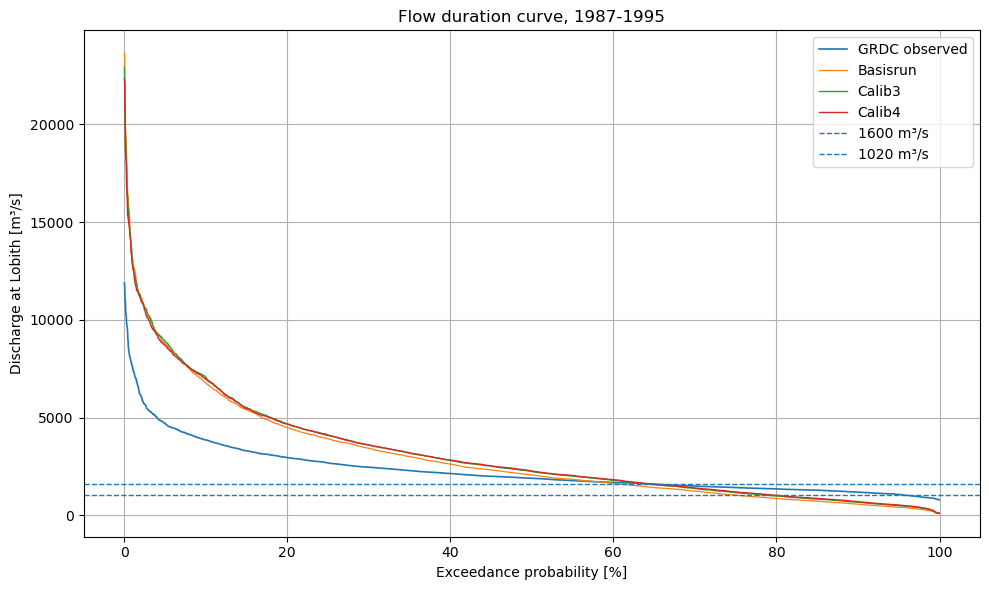

In [42]:
plt.figure(figsize=(10, 6))

plt.plot(fdc4["exceedance"], fdc4["GRDC"], label="GRDC observed", linewidth=1.2)
plt.plot(fdc4["exceedance"], fdc4["Basisrun"], label="Basisrun", linewidth=0.9)
plt.plot(fdc4["exceedance"], fdc4["Calib3"], label="Calib3", linewidth=1.0)
plt.plot(fdc4["exceedance"], fdc4["Calib4"], label="Calib4", linewidth=1.0)

plt.axhline(1600, linestyle="--", linewidth=1, label="1600 m³/s")
plt.axhline(1020, linestyle="--", linewidth=1, label="1020 m³/s")

plt.xlabel("Exceedance probability [%]")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("Flow duration curve, 1987-1995")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
pet_factor = 0.90

forcing_pet_dir = temp_dir / "forcing_pet_x0p90_1987_1995"
forcing_pet_dir.mkdir(exist_ok=True)

forcing_pet_file = forcing_pet_dir / "wflow_ERA5_Rhine_1986_1995_pet_x0p90.nc"

if forcing_pet_file.exists():
    print("PET x0.90 forcing bestaat al:")
    print(forcing_pet_file)

else:
    ds = xr.open_dataset(forcing_file)
    ds_new = ds.copy()

    ds_new["pet"] = ds_new["pet"] * pet_factor

    ds_new.to_netcdf(forcing_pet_file)

    ds.close()
    ds_new.close()

    print("PET x0.90 forcing opgeslagen:")
    print(forcing_pet_file)

PET x0.90 forcing opgeslagen:
/home/niels/BEP-Niels/temp_runs/forcing_pet_x0p90_1987_1995/wflow_ERA5_Rhine_1986_1995_pet_x0p90.nc


In [45]:
forcing_pet_090 = WflowForcing(
    start_time=model_start,
    end_time=model_end,
    directory=str(forcing_pet_file.parent),
    netcdfinput=forcing_pet_file.name,
    Precipitation="/pr",
    EvapoTranspiration="/pet",
    Temperature="/tas",
    Inflow=None,
)

print("PET x0.90 forcing gekoppeld")

PET x0.90 forcing gekoppeld


In [46]:
run_name = "calib5_PET_x0p90_NRiver_x1p50_N_x1p25"
run_dir = temp_dir / run_name

parameters = {
    "N_River.tbl": 1.50,
    "N.tbl": 1.25,
}

print("Run:", run_name)
print("Runmap:", run_dir)

for parameter_name, factor in parameters.items():
    print(parameter_name, "x", factor)

Run: calib5_PET_x0p90_NRiver_x1p50_N_x1p25
Runmap: /home/niels/BEP-Niels/temp_runs/calib5_PET_x0p90_NRiver_x1p50_N_x1p25
N_River.tbl x 1.5
N.tbl x 1.25


In [47]:
if run_dir.exists():
    shutil.rmtree(run_dir)

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing_pet_090
)

cfg_file, cfg_dir = model.setup(cfg_dir=str(run_dir))
cfg_dir = Path(cfg_dir)

for parameter_name, factor in parameters.items():
    tbl_files = list(cfg_dir.rglob(parameter_name))

    print("\nParameter:", parameter_name)
    print("Aantal gevonden bestanden:", len(tbl_files))

    for tbl_file in tbl_files:
        print("Aanpassen:", tbl_file)
        multiply_tbl(tbl_file, factor)


Parameter: N_River.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib5_PET_x0p90_NRiver_x1p50_N_x1p25/intbl/N_River.tbl

Parameter: N.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib5_PET_x0p90_NRiver_x1p50_N_x1p25/intbl/N.tbl


In [48]:
model.initialize(cfg_file)

dates = []
q_values = []

step = 0

while model.time < model.end_time:
    model.update()

    q = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat_lobith],
        lon=[lon_lobith]
    )[0]

    dates.append(model.time_as_datetime)
    q_values.append(float(q))

    step += 1

    if step % 365 == 0:
        print(step, model.time_as_datetime, round(float(q), 1))

model.finalize()

print("Run klaar")

365 1986-12-31 00:00:00 11261.1
730 1987-12-31 00:00:00 3046.6
1095 1988-12-30 00:00:00 5066.1
1460 1989-12-30 00:00:00 6419.2
1825 1990-12-30 00:00:00 5945.2
2190 1991-12-30 00:00:00 9639.0
2555 1992-12-29 00:00:00 2436.4
2920 1993-12-29 00:00:00 12657.2
3285 1994-12-29 00:00:00 4105.6
3650 1995-12-29 00:00:00 9837.6
Run klaar


In [49]:
model_calib5 = pd.DataFrame({
    "date": pd.to_datetime(dates, utc=True),
    "Q_model_m3s": q_values
})

model_calib5["date"] = model_calib5["date"].dt.tz_convert(None).dt.floor("D")

model_calib5 = model_calib5[
    (model_calib5["date"] >= calibration_start) &
    (model_calib5["date"] <= calibration_end)
].copy()

output_file = parameter_results_dir / f"{run_name}_lobith_daily.csv"

model_calib5.to_csv(output_file, index=False)

print("Aantal dagen:", len(model_calib5))
print("Opgeslagen als:", output_file)

Aantal dagen: 3287
Opgeslagen als: /home/niels/BEP-Niels/results/Parameter_Gevoeligheid/calib5_PET_x0p90_NRiver_x1p50_N_x1p25_lobith_daily.csv


In [50]:
comparison_calib5 = pd.merge(
    grdc_calibration,
    model_calib5,
    on="date",
    how="inner"
)

scores_calib5 = scores(comparison_calib5)

pd.DataFrame(
    [basis_scores_full, scores_calib5],
    index=["basis_full", run_name]
).round(2)

,bias,rmse,log_nse,bias_low_1600,mae_low_1600,grdc_days_below_1600,model_days_below_1600,diff_days_below_1600,grdc_days_below_1020,model_days_below_1020,diff_days_below_1020,grdc_p10,model_p10,diff_p10,grdc_p17,model_p17,diff_p17
basis_full,710.10,1998.63,-0.94,-116.22,575.02,1150,1291,141,125,812,687,1187.2,572.26,-614.94,1310.62,779.24,-531.38
calib5_PET_x0p90_NRiver_x1p50_N_x1p25,986.96,2065.66,-0.64,124.87,592.63,1150,1063,-87,125,596,471,1187.2,749.86,-437.34,1310.62,975.40,-335.22


In [51]:
forcing_pet_095_file = temp_dir / "forcing_pet_x0p95_1987_1995" / "wflow_ERA5_Rhine_1986_1995_pet_x0p95.nc"

print("PET x0.95 forcing bestaat:", forcing_pet_095_file.exists())

forcing_pet_095 = WflowForcing(
    start_time=model_start,
    end_time=model_end,
    directory=str(forcing_pet_095_file.parent),
    netcdfinput=forcing_pet_095_file.name,
    Precipitation="/pr",
    EvapoTranspiration="/pet",
    Temperature="/tas",
    Inflow=None,
)

print("PET x0.95 forcing gekoppeld")

PET x0.95 forcing bestaat: True
PET x0.95 forcing gekoppeld


In [52]:
run_name = "calib6_PET_x0p95_CanopyGap_x1p25_NRiver_x1p50_N_x1p25"
run_dir = temp_dir / run_name

parameters = {
    "N_River.tbl": 1.50,
    "N.tbl": 1.25,
}

fraction_parameters = {
    "CanopyGapFraction.tbl": 1.25,
}

print("Run:", run_name)
print("Runmap:", run_dir)

print("\nNormale parameters:")
for parameter_name, factor in parameters.items():
    print(parameter_name, "x", factor)

print("\nFractie-parameters:")
for parameter_name, factor in fraction_parameters.items():
    print(parameter_name, "x", factor)

Run: calib6_PET_x0p95_CanopyGap_x1p25_NRiver_x1p50_N_x1p25
Runmap: /home/niels/BEP-Niels/temp_runs/calib6_PET_x0p95_CanopyGap_x1p25_NRiver_x1p50_N_x1p25

Normale parameters:
N_River.tbl x 1.5
N.tbl x 1.25

Fractie-parameters:
CanopyGapFraction.tbl x 1.25


In [54]:
def multiply_tbl_max1(tbl_file, factor):
    lines = Path(tbl_file).read_text().splitlines()
    new_lines = []

    for line in lines:
        parts = line.split()

        try:
            value = float(parts[-1])
            value_new = value * factor
            value_new = min(value_new, 1.0)

            parts[-1] = str(value_new)
            new_lines.append(" ".join(parts))
        except:
            new_lines.append(line)

    Path(tbl_file).write_text("\n".join(new_lines))

In [55]:
if run_dir.exists():
    shutil.rmtree(run_dir)

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing_pet_095
)

cfg_file, cfg_dir = model.setup(cfg_dir=str(run_dir))
cfg_dir = Path(cfg_dir)

for parameter_name, factor in parameters.items():
    tbl_files = list(cfg_dir.rglob(parameter_name))

    print("\nParameter:", parameter_name)
    print("Aantal gevonden bestanden:", len(tbl_files))

    for tbl_file in tbl_files:
        print("Aanpassen:", tbl_file)
        multiply_tbl(tbl_file, factor)

for parameter_name, factor in fraction_parameters.items():
    tbl_files = list(cfg_dir.rglob(parameter_name))

    print("\nParameter:", parameter_name)
    print("Aantal gevonden bestanden:", len(tbl_files))

    for tbl_file in tbl_files:
        print("Aanpassen:", tbl_file)
        multiply_tbl_max1(tbl_file, factor)


Parameter: N_River.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib6_PET_x0p95_CanopyGap_x1p25_NRiver_x1p50_N_x1p25/intbl/N_River.tbl

Parameter: N.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib6_PET_x0p95_CanopyGap_x1p25_NRiver_x1p50_N_x1p25/intbl/N.tbl

Parameter: CanopyGapFraction.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib6_PET_x0p95_CanopyGap_x1p25_NRiver_x1p50_N_x1p25/intbl/CanopyGapFraction.tbl


In [56]:
model.initialize(cfg_file)

dates = []
q_values = []

step = 0

while model.time < model.end_time:
    model.update()

    q = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat_lobith],
        lon=[lon_lobith]
    )[0]

    dates.append(model.time_as_datetime)
    q_values.append(float(q))

    step += 1

    if step % 365 == 0:
        print(step, model.time_as_datetime, round(float(q), 1))

model.finalize()

print("Run klaar")

365 1986-12-31 00:00:00 11217.3
730 1987-12-31 00:00:00 3054.6
1095 1988-12-30 00:00:00 5022.2
1460 1989-12-30 00:00:00 6278.9
1825 1990-12-30 00:00:00 5882.0
2190 1991-12-30 00:00:00 9485.9
2555 1992-12-29 00:00:00 2423.1
2920 1993-12-29 00:00:00 12623.8
3285 1994-12-29 00:00:00 4060.3
3650 1995-12-29 00:00:00 9669.2
Run klaar


In [57]:
model_calib6 = pd.DataFrame({
    "date": pd.to_datetime(dates, utc=True),
    "Q_model_m3s": q_values
})

model_calib6["date"] = model_calib6["date"].dt.tz_convert(None).dt.floor("D")

model_calib6 = model_calib6[
    (model_calib6["date"] >= calibration_start) &
    (model_calib6["date"] <= calibration_end)
].copy()

output_file = parameter_results_dir / f"{run_name}_lobith_daily.csv"

model_calib6.to_csv(output_file, index=False)

print("Aantal dagen:", len(model_calib6))
print("Opgeslagen als:", output_file)

Aantal dagen: 3287
Opgeslagen als: /home/niels/BEP-Niels/results/Parameter_Gevoeligheid/calib6_PET_x0p95_CanopyGap_x1p25_NRiver_x1p50_N_x1p25_lobith_daily.csv


In [58]:
comparison_calib6 = pd.merge(
    grdc_calibration,
    model_calib6,
    on="date",
    how="inner"
)

scores_calib6 = scores(comparison_calib6)

pd.DataFrame(
    [basis_scores_full, scores_calib6],
    index=["basis_full", run_name]
).round(2)

,bias,rmse,log_nse,bias_low_1600,mae_low_1600,grdc_days_below_1600,model_days_below_1600,diff_days_below_1600,grdc_days_below_1020,model_days_below_1020,diff_days_below_1020,grdc_p10,model_p10,diff_p10,grdc_p17,model_p17,diff_p17
basis_full,710.10,1998.63,-0.94,-116.22,575.02,1150,1291,141,125,812,687,1187.2,572.26,-614.94,1310.62,779.24,-531.38
calib6_PET_x0p95_CanopyGap_x1p25_NRiver_x1p50_N_x1p25,1010.59,2024.38,-0.49,186.26,590.97,1150,1012,-138,125,519,394,1187.2,817.17,-370.03,1310.62,1067.30,-243.32


In [59]:
forcing_pet_090_file = temp_dir / "forcing_pet_x0p90_1987_1995" / "wflow_ERA5_Rhine_1986_1995_pet_x0p90.nc"

print("PET x0.90 forcing bestaat:", forcing_pet_090_file.exists())

forcing_pet_090 = WflowForcing(
    start_time=model_start,
    end_time=model_end,
    directory=str(forcing_pet_090_file.parent),
    netcdfinput=forcing_pet_090_file.name,
    Precipitation="/pr",
    EvapoTranspiration="/pet",
    Temperature="/tas",
    Inflow=None,
)

print("PET x0.90 forcing gekoppeld")

PET x0.90 forcing bestaat: True
PET x0.90 forcing gekoppeld


In [60]:
run_name = "calib7_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25"
run_dir = temp_dir / run_name

parameters = {
    "N_River.tbl": 1.50,
    "N.tbl": 1.25,
}

fraction_parameters = {
    "CanopyGapFraction.tbl": 1.25,
}

print("Run:", run_name)
print("Runmap:", run_dir)

print("\nNormale parameters:")
for parameter_name, factor in parameters.items():
    print(parameter_name, "x", factor)

print("\nFractie-parameters:")
for parameter_name, factor in fraction_parameters.items():
    print(parameter_name, "x", factor)

Run: calib7_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25
Runmap: /home/niels/BEP-Niels/temp_runs/calib7_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25

Normale parameters:
N_River.tbl x 1.5
N.tbl x 1.25

Fractie-parameters:
CanopyGapFraction.tbl x 1.25


In [61]:
if run_dir.exists():
    shutil.rmtree(run_dir)

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing_pet_090
)

cfg_file, cfg_dir = model.setup(cfg_dir=str(run_dir))
cfg_dir = Path(cfg_dir)

for parameter_name, factor in parameters.items():
    tbl_files = list(cfg_dir.rglob(parameter_name))

    print("\nParameter:", parameter_name)
    print("Aantal gevonden bestanden:", len(tbl_files))

    for tbl_file in tbl_files:
        print("Aanpassen:", tbl_file)
        multiply_tbl(tbl_file, factor)

for parameter_name, factor in fraction_parameters.items():
    tbl_files = list(cfg_dir.rglob(parameter_name))

    print("\nParameter:", parameter_name)
    print("Aantal gevonden bestanden:", len(tbl_files))

    for tbl_file in tbl_files:
        print("Aanpassen:", tbl_file)
        multiply_tbl_max1(tbl_file, factor)


Parameter: N_River.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib7_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25/intbl/N_River.tbl

Parameter: N.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib7_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25/intbl/N.tbl

Parameter: CanopyGapFraction.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib7_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25/intbl/CanopyGapFraction.tbl


In [62]:
model.initialize(cfg_file)

dates = []
q_values = []

step = 0

while model.time < model.end_time:
    model.update()

    q = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat_lobith],
        lon=[lon_lobith]
    )[0]

    dates.append(model.time_as_datetime)
    q_values.append(float(q))

    step += 1

    if step % 365 == 0:
        print(step, model.time_as_datetime, round(float(q), 1))

model.finalize()

print("Run klaar")

365 1986-12-31 00:00:00 11273.4
730 1987-12-31 00:00:00 3090.2
1095 1988-12-30 00:00:00 5095.6
1460 1989-12-30 00:00:00 6479.8
1825 1990-12-30 00:00:00 5988.4
2190 1991-12-30 00:00:00 9752.7
2555 1992-12-29 00:00:00 2453.7
2920 1993-12-29 00:00:00 12663.1
3285 1994-12-29 00:00:00 4158.3
3650 1995-12-29 00:00:00 9958.5
Run klaar


In [63]:
model_calib7 = pd.DataFrame({
    "date": pd.to_datetime(dates, utc=True),
    "Q_model_m3s": q_values
})

model_calib7["date"] = model_calib7["date"].dt.tz_convert(None).dt.floor("D")

model_calib7 = model_calib7[
    (model_calib7["date"] >= calibration_start) &
    (model_calib7["date"] <= calibration_end)
].copy()

output_file = parameter_results_dir / f"{run_name}_lobith_daily.csv"

model_calib7.to_csv(output_file, index=False)

print("Aantal dagen:", len(model_calib7))
print("Opgeslagen als:", output_file)

Aantal dagen: 3287
Opgeslagen als: /home/niels/BEP-Niels/results/Parameter_Gevoeligheid/calib7_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25_lobith_daily.csv


In [64]:
comparison_calib7 = pd.merge(
    grdc_calibration,
    model_calib7,
    on="date",
    how="inner"
)

scores_calib7 = scores(comparison_calib7)

pd.DataFrame(
    [basis_scores_full, scores_calib7],
    index=["basis_full", run_name]
).round(2)

,bias,rmse,log_nse,bias_low_1600,mae_low_1600,grdc_days_below_1600,model_days_below_1600,diff_days_below_1600,grdc_days_below_1020,model_days_below_1020,diff_days_below_1020,grdc_p10,model_p10,diff_p10,grdc_p17,model_p17,diff_p17
basis_full,710.10,1998.63,-0.94,-116.22,575.02,1150,1291,141,125,812,687,1187.2,572.26,-614.94,1310.62,779.24,-531.38
calib7_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25,1141.89,2148.31,-0.57,268.01,634.10,1150,952,-198,125,477,352,1187.2,861.92,-325.28,1310.62,1127.49,-183.13


In [65]:
p_factor = 0.95
pet_factor = 0.90

forcing_calib8_dir = temp_dir / "forcing_pr_x0p95_pet_x0p90_1987_1995"
forcing_calib8_dir.mkdir(exist_ok=True)

forcing_calib8_file = forcing_calib8_dir / "wflow_ERA5_Rhine_1986_1995_pr_x0p95_pet_x0p90.nc"

if forcing_calib8_file.exists():
    print("Forcing voor calib8 bestaat al:")
    print(forcing_calib8_file)

else:
    ds = xr.open_dataset(forcing_file)
    ds_new = ds.copy()

    ds_new["pr"] = ds_new["pr"] * p_factor
    ds_new["pet"] = ds_new["pet"] * pet_factor

    ds_new.to_netcdf(forcing_calib8_file)

    ds.close()
    ds_new.close()

    print("Nieuwe forcing voor calib8 opgeslagen:")
    print(forcing_calib8_file)

Nieuwe forcing voor calib8 opgeslagen:
/home/niels/BEP-Niels/temp_runs/forcing_pr_x0p95_pet_x0p90_1987_1995/wflow_ERA5_Rhine_1986_1995_pr_x0p95_pet_x0p90.nc


In [66]:
forcing_calib8 = WflowForcing(
    start_time=model_start,
    end_time=model_end,
    directory=str(forcing_calib8_file.parent),
    netcdfinput=forcing_calib8_file.name,
    Precipitation="/pr",
    EvapoTranspiration="/pet",
    Temperature="/tas",
    Inflow=None,
)

print("Calib8 forcing gekoppeld")

Calib8 forcing gekoppeld


In [67]:
run_name = "calib8_P_x0p95_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25"
run_dir = temp_dir / run_name

parameters = {
    "N_River.tbl": 1.50,
    "N.tbl": 1.25,
}

fraction_parameters = {
    "CanopyGapFraction.tbl": 1.25,
}

print("Run:", run_name)
print("Runmap:", run_dir)

print("\nNormale parameters:")
for parameter_name, factor in parameters.items():
    print(parameter_name, "x", factor)

print("\nFractie-parameters:")
for parameter_name, factor in fraction_parameters.items():
    print(parameter_name, "x", factor)

Run: calib8_P_x0p95_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25
Runmap: /home/niels/BEP-Niels/temp_runs/calib8_P_x0p95_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25

Normale parameters:
N_River.tbl x 1.5
N.tbl x 1.25

Fractie-parameters:
CanopyGapFraction.tbl x 1.25


In [68]:
if run_dir.exists():
    shutil.rmtree(run_dir)

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing_calib8
)

cfg_file, cfg_dir = model.setup(cfg_dir=str(run_dir))
cfg_dir = Path(cfg_dir)

for parameter_name, factor in parameters.items():
    tbl_files = list(cfg_dir.rglob(parameter_name))

    print("\nParameter:", parameter_name)
    print("Aantal gevonden bestanden:", len(tbl_files))

    for tbl_file in tbl_files:
        print("Aanpassen:", tbl_file)
        multiply_tbl(tbl_file, factor)

for parameter_name, factor in fraction_parameters.items():
    tbl_files = list(cfg_dir.rglob(parameter_name))

    print("\nParameter:", parameter_name)
    print("Aantal gevonden bestanden:", len(tbl_files))

    for tbl_file in tbl_files:
        print("Aanpassen:", tbl_file)
        multiply_tbl_max1(tbl_file, factor)


Parameter: N_River.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib8_P_x0p95_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25/intbl/N_River.tbl

Parameter: N.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib8_P_x0p95_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25/intbl/N.tbl

Parameter: CanopyGapFraction.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib8_P_x0p95_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25/intbl/CanopyGapFraction.tbl


In [69]:
model.initialize(cfg_file)

dates = []
q_values = []

step = 0

while model.time < model.end_time:
    model.update()

    q = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat_lobith],
        lon=[lon_lobith]
    )[0]

    dates.append(model.time_as_datetime)
    q_values.append(float(q))

    step += 1

    if step % 365 == 0:
        print(step, model.time_as_datetime, round(float(q), 1))

model.finalize()

print("Run klaar")

365 1986-12-31 00:00:00 10622.1
730 1987-12-31 00:00:00 2955.5
1095 1988-12-30 00:00:00 4839.8
1460 1989-12-30 00:00:00 6069.4
1825 1990-12-30 00:00:00 5535.0
2190 1991-12-30 00:00:00 9110.4
2555 1992-12-29 00:00:00 2348.6
2920 1993-12-29 00:00:00 12138.6
3285 1994-12-29 00:00:00 3784.6
3650 1995-12-29 00:00:00 9023.2
Run klaar


In [70]:
model_calib8 = pd.DataFrame({
    "date": pd.to_datetime(dates, utc=True),
    "Q_model_m3s": q_values
})

model_calib8["date"] = model_calib8["date"].dt.tz_convert(None).dt.floor("D")

model_calib8 = model_calib8[
    (model_calib8["date"] >= calibration_start) &
    (model_calib8["date"] <= calibration_end)
].copy()

output_file = parameter_results_dir / f"{run_name}_lobith_daily.csv"

model_calib8.to_csv(output_file, index=False)

print("Aantal dagen:", len(model_calib8))
print("Opgeslagen als:", output_file)

Aantal dagen: 3287
Opgeslagen als: /home/niels/BEP-Niels/results/Parameter_Gevoeligheid/calib8_P_x0p95_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25_lobith_daily.csv


In [71]:
comparison_calib8 = pd.merge(
    grdc_calibration,
    model_calib8,
    on="date",
    how="inner"
)

scores_calib8 = scores(comparison_calib8)

pd.DataFrame(
    [basis_scores_full, scores_calib8],
    index=["basis_full", run_name]
).round(2)

,bias,rmse,log_nse,bias_low_1600,mae_low_1600,grdc_days_below_1600,model_days_below_1600,diff_days_below_1600,grdc_days_below_1020,model_days_below_1020,diff_days_below_1020,grdc_p10,model_p10,diff_p10,grdc_p17,model_p17,diff_p17
basis_full,710.10,1998.63,-0.94,-116.22,575.02,1150,1291,141,125,812,687,1187.2,572.26,-614.94,1310.62,779.24,-531.38
calib8_P_x0p95_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25,849.88,1825.65,-0.40,122.85,559.31,1150,1071,-79,125,553,428,1187.2,793.47,-393.73,1310.62,1026.88,-283.74


In [72]:
run_name = "calib9_PET_x0p90_CanopyGap_x1p25_NRiver_x1p75_N_x1p25"
run_dir = temp_dir / run_name

parameters = {
    "N_River.tbl": 1.75,
    "N.tbl": 1.25,
}

fraction_parameters = {
    "CanopyGapFraction.tbl": 1.25,
}

print("Run:", run_name)
print("Runmap:", run_dir)

print("\nNormale parameters:")
for parameter_name, factor in parameters.items():
    print(parameter_name, "x", factor)

print("\nFractie-parameters:")
for parameter_name, factor in fraction_parameters.items():
    print(parameter_name, "x", factor)

Run: calib9_PET_x0p90_CanopyGap_x1p25_NRiver_x1p75_N_x1p25
Runmap: /home/niels/BEP-Niels/temp_runs/calib9_PET_x0p90_CanopyGap_x1p25_NRiver_x1p75_N_x1p25

Normale parameters:
N_River.tbl x 1.75
N.tbl x 1.25

Fractie-parameters:
CanopyGapFraction.tbl x 1.25


In [73]:
if run_dir.exists():
    shutil.rmtree(run_dir)

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing_pet_090
)

cfg_file, cfg_dir = model.setup(cfg_dir=str(run_dir))
cfg_dir = Path(cfg_dir)

for parameter_name, factor in parameters.items():
    tbl_files = list(cfg_dir.rglob(parameter_name))

    print("\nParameter:", parameter_name)
    print("Aantal gevonden bestanden:", len(tbl_files))

    for tbl_file in tbl_files:
        print("Aanpassen:", tbl_file)
        multiply_tbl(tbl_file, factor)

for parameter_name, factor in fraction_parameters.items():
    tbl_files = list(cfg_dir.rglob(parameter_name))

    print("\nParameter:", parameter_name)
    print("Aantal gevonden bestanden:", len(tbl_files))

    for tbl_file in tbl_files:
        print("Aanpassen:", tbl_file)
        multiply_tbl_max1(tbl_file, factor)


Parameter: N_River.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib9_PET_x0p90_CanopyGap_x1p25_NRiver_x1p75_N_x1p25/intbl/N_River.tbl

Parameter: N.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib9_PET_x0p90_CanopyGap_x1p25_NRiver_x1p75_N_x1p25/intbl/N.tbl

Parameter: CanopyGapFraction.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib9_PET_x0p90_CanopyGap_x1p25_NRiver_x1p75_N_x1p25/intbl/CanopyGapFraction.tbl


In [74]:
model.initialize(cfg_file)

dates = []
q_values = []

step = 0

while model.time < model.end_time:
    model.update()

    q = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat_lobith],
        lon=[lon_lobith]
    )[0]

    dates.append(model.time_as_datetime)
    q_values.append(float(q))

    step += 1

    if step % 365 == 0:
        print(step, model.time_as_datetime, round(float(q), 1))

model.finalize()

print("Run klaar")

365 1986-12-31 00:00:00 11186.4
730 1987-12-31 00:00:00 3300.1
1095 1988-12-30 00:00:00 5376.4
1460 1989-12-30 00:00:00 6887.5
1825 1990-12-30 00:00:00 5810.5
2190 1991-12-30 00:00:00 10254.1
2555 1992-12-29 00:00:00 2669.6
2920 1993-12-29 00:00:00 13230.5
3285 1994-12-29 00:00:00 3853.3
3650 1995-12-29 00:00:00 9165.7
Run klaar


In [75]:
model_calib9 = pd.DataFrame({
    "date": pd.to_datetime(dates, utc=True),
    "Q_model_m3s": q_values
})

model_calib9["date"] = model_calib9["date"].dt.tz_convert(None).dt.floor("D")

model_calib9 = model_calib9[
    (model_calib9["date"] >= calibration_start) &
    (model_calib9["date"] <= calibration_end)
].copy()

output_file = parameter_results_dir / f"{run_name}_lobith_daily.csv"

model_calib9.to_csv(output_file, index=False)

print("Aantal dagen:", len(model_calib9))
print("Opgeslagen als:", output_file)

Aantal dagen: 3287
Opgeslagen als: /home/niels/BEP-Niels/results/Parameter_Gevoeligheid/calib9_PET_x0p90_CanopyGap_x1p25_NRiver_x1p75_N_x1p25_lobith_daily.csv


In [76]:
comparison_calib9 = pd.merge(
    grdc_calibration,
    model_calib9,
    on="date",
    how="inner"
)

scores_calib9 = scores(comparison_calib9)

pd.DataFrame(
    [basis_scores_full, scores_calib9],
    index=["basis_full", run_name]
).round(2)

,bias,rmse,log_nse,bias_low_1600,mae_low_1600,grdc_days_below_1600,model_days_below_1600,diff_days_below_1600,grdc_days_below_1020,model_days_below_1020,diff_days_below_1020,grdc_p10,model_p10,diff_p10,grdc_p17,model_p17,diff_p17
basis_full,710.1,1998.63,-0.94,-116.22,575.02,1150,1291,141,125,812,687,1187.2,572.26,-614.94,1310.62,779.24,-531.38
calib9_PET_x0p90_CanopyGap_x1p25_NRiver_x1p75_N_x1p25,1141.6,2104.75,-0.53,303.00,638.12,1150,920,-230,125,443,318,1187.2,892.37,-294.83,1310.62,1161.19,-149.43


In [77]:
pd.DataFrame(
    [
        basis_scores_full,
        scores_calib1,
        scores_calib2,
        scores_calib3,
        scores_calib4,
        scores_calib5,
        scores_calib6,
        scores_calib7,
        scores_calib8,
        scores_calib9
    ],
    index=[
        "basis_full",
        "calib1_NRiver_x1p25_N_x1p25",
        "calib2_PET_x0p95_NRiver_x1p25",
        "calib3_PET_x0p95_NRiver_x1p25_N_x1p25",
        "calib4_PET_x0p95_NRiver_x1p50_N_x1p25",
        "calib5_PET_x0p90_NRiver_x1p50_N_x1p25",
        "calib6_PET_x0p95_CanopyGap_x1p25_NRiver_x1p50_N_x1p25",
        "calib7_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25",
        "calib8_P_x0p95_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25",
        "calib9_PET_x0p90_CanopyGap_x1p25_NRiver_x1p75_N_x1p25"
    ]
).round(2)

,bias,rmse,log_nse,bias_low_1600,mae_low_1600,grdc_days_below_1600,model_days_below_1600,diff_days_below_1600,grdc_days_below_1020,model_days_below_1020,diff_days_below_1020,grdc_p10,model_p10,diff_p10,grdc_p17,model_p17,diff_p17
basis_full,710.10,1998.63,-0.94,-116.22,575.02,1150,1291,141,125,812,687,1187.2,572.26,-614.94,1310.62,779.24,-531.38
calib1_NRiver_x1p25_N_x1p25,709.39,1874.04,-0.69,-76.24,540.51,1150,1247,97,125,762,637,1187.2,629.46,-557.74,1310.62,835.37,-475.25
calib2_PET_x0p95_NRiver_x1p25,847.56,2037.71,-0.78,-9.33,574.82,1150,1191,41,125,707,582,1187.2,642.60,-544.60,1310.62,862.45,-448.17
calib3_PET_x0p95_NRiver_x1p25_N_x1p25,847.14,1997.49,-0.69,5.00,563.47,1150,1182,32,125,690,565,1187.2,674.99,-512.21,1310.62,889.36,-421.26
calib4_PET_x0p95_NRiver_x1p50_N_x1p25,846.81,1941.80,-0.60,37.91,558.34,1150,1152,2,125,656,531,1187.2,703.10,-484.10,1310.62,920.33,-390.29
calib5_PET_x0p90_NRiver_x1p50_N_x1p25,986.96,2065.66,-0.64,124.87,592.63,1150,1063,-87,125,596,471,1187.2,749.86,-437.34,1310.62,975.40,-335.22
calib6_PET_x0p95_CanopyGap_x1p25_NRiver_x1p50_N_x1p25,1010.59,2024.38,-0.49,186.26,590.97,1150,1012,-138,125,519,394,1187.2,817.17,-370.03,1310.62,1067.30,-243.32
calib7_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25,1141.89,2148.31,-0.57,268.01,634.10,1150,952,-198,125,477,352,1187.2,861.92,-325.28,1310.62,1127.49,-183.13
calib8_P_x0p95_PET_x0p90_CanopyGap_x1p25_NRiver_x1p50_N_x1p25,849.88,1825.65,-0.40,122.85,559.31,1150,1071,-79,125,553,428,1187.2,793.47,-393.73,1310.62,1026.88,-283.74
calib9_PET_x0p90_CanopyGap_x1p25_NRiver_x1p75_N_x1p25,1141.60,2104.75,-0.53,303.00,638.12,1150,920,-230,125,443,318,1187.2,892.37,-294.83,1310.62,1161.19,-149.43


In [78]:
run_name = "calib10_PET_x0p90_CanopyGap_x1p25_NRiver_x2p00_N_x1p25"
run_dir = temp_dir / run_name

parameters = {
    "N_River.tbl": 2.00,
    "N.tbl": 1.25,
}

fraction_parameters = {
    "CanopyGapFraction.tbl": 1.25,
}

print("Run:", run_name)
print("Runmap:", run_dir)

print("\nNormale parameters:")
for parameter_name, factor in parameters.items():
    print(parameter_name, "x", factor)

print("\nFractie-parameters:")
for parameter_name, factor in fraction_parameters.items():
    print(parameter_name, "x", factor)

Run: calib10_PET_x0p90_CanopyGap_x1p25_NRiver_x2p00_N_x1p25
Runmap: /home/niels/BEP-Niels/temp_runs/calib10_PET_x0p90_CanopyGap_x1p25_NRiver_x2p00_N_x1p25

Normale parameters:
N_River.tbl x 2.0
N.tbl x 1.25

Fractie-parameters:
CanopyGapFraction.tbl x 1.25


In [79]:
if run_dir.exists():
    shutil.rmtree(run_dir)

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing_pet_090
)

cfg_file, cfg_dir = model.setup(cfg_dir=str(run_dir))
cfg_dir = Path(cfg_dir)

for parameter_name, factor in parameters.items():
    tbl_files = list(cfg_dir.rglob(parameter_name))

    print("\nParameter:", parameter_name)
    print("Aantal gevonden bestanden:", len(tbl_files))

    for tbl_file in tbl_files:
        print("Aanpassen:", tbl_file)
        multiply_tbl(tbl_file, factor)

for parameter_name, factor in fraction_parameters.items():
    tbl_files = list(cfg_dir.rglob(parameter_name))

    print("\nParameter:", parameter_name)
    print("Aantal gevonden bestanden:", len(tbl_files))

    for tbl_file in tbl_files:
        print("Aanpassen:", tbl_file)
        multiply_tbl_max1(tbl_file, factor)


Parameter: N_River.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib10_PET_x0p90_CanopyGap_x1p25_NRiver_x2p00_N_x1p25/intbl/N_River.tbl

Parameter: N.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib10_PET_x0p90_CanopyGap_x1p25_NRiver_x2p00_N_x1p25/intbl/N.tbl

Parameter: CanopyGapFraction.tbl
Aantal gevonden bestanden: 1
Aanpassen: /home/niels/BEP-Niels/temp_runs/calib10_PET_x0p90_CanopyGap_x1p25_NRiver_x2p00_N_x1p25/intbl/CanopyGapFraction.tbl


In [80]:
model.initialize(cfg_file)

dates = []
q_values = []

step = 0

while model.time < model.end_time:
    model.update()

    q = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat_lobith],
        lon=[lon_lobith]
    )[0]

    dates.append(model.time_as_datetime)
    q_values.append(float(q))

    step += 1

    if step % 365 == 0:
        print(step, model.time_as_datetime, round(float(q), 1))

model.finalize()

print("Run klaar")

365 1986-12-31 00:00:00 11128.6
730 1987-12-31 00:00:00 3442.1
1095 1988-12-30 00:00:00 5604.0
1460 1989-12-30 00:00:00 7180.7
1825 1990-12-30 00:00:00 5696.7
2190 1991-12-30 00:00:00 10408.8
2555 1992-12-29 00:00:00 2877.1
2920 1993-12-29 00:00:00 13761.0
3285 1994-12-29 00:00:00 3696.0
3650 1995-12-29 00:00:00 8315.6
Run klaar


In [81]:
model_calib10 = pd.DataFrame({
    "date": pd.to_datetime(dates, utc=True),
    "Q_model_m3s": q_values
})

model_calib10["date"] = model_calib10["date"].dt.tz_convert(None).dt.floor("D")

model_calib10 = model_calib10[
    (model_calib10["date"] >= calibration_start) &
    (model_calib10["date"] <= calibration_end)
].copy()

output_file = parameter_results_dir / f"{run_name}_lobith_daily.csv"

model_calib10.to_csv(output_file, index=False)

print("Aantal dagen:", len(model_calib10))
print("Opgeslagen als:", output_file)

Aantal dagen: 3287
Opgeslagen als: /home/niels/BEP-Niels/results/Parameter_Gevoeligheid/calib10_PET_x0p90_CanopyGap_x1p25_NRiver_x2p00_N_x1p25_lobith_daily.csv


In [82]:
comparison_calib10 = pd.merge(
    grdc_calibration,
    model_calib10,
    on="date",
    how="inner"
)

scores_calib10 = scores(comparison_calib10)

pd.DataFrame(
    [basis_scores_full, scores_calib10],
    index=["basis_full", run_name]
).round(2)

,bias,rmse,log_nse,bias_low_1600,mae_low_1600,grdc_days_below_1600,model_days_below_1600,diff_days_below_1600,grdc_days_below_1020,model_days_below_1020,diff_days_below_1020,grdc_p10,model_p10,diff_p10,grdc_p17,model_p17,diff_p17
basis_full,710.10,1998.63,-0.94,-116.22,575.02,1150,1291,141,125,812,687,1187.2,572.26,-614.94,1310.62,779.24,-531.38
calib10_PET_x0p90_CanopyGap_x1p25_NRiver_x2p00_N_x1p25,1141.46,2072.46,-0.50,339.38,649.52,1150,895,-255,125,411,286,1187.2,920.48,-266.72,1310.62,1196.12,-114.50


In [83]:
comparison_calib10 = pd.merge(
    grdc_calibration,
    model_calib10,
    on="date",
    how="inner"
)

comparison_calib10.head()

,date,Q_grdc_m3s,Q_model_m3s
0,1987-01-01,4865.0,12101.763672
1,1987-01-02,5756.0,13396.190430
2,1987-01-03,6160.0,14481.406250
3,1987-01-04,6973.0,14916.130859
4,1987-01-05,7579.0,14704.667969


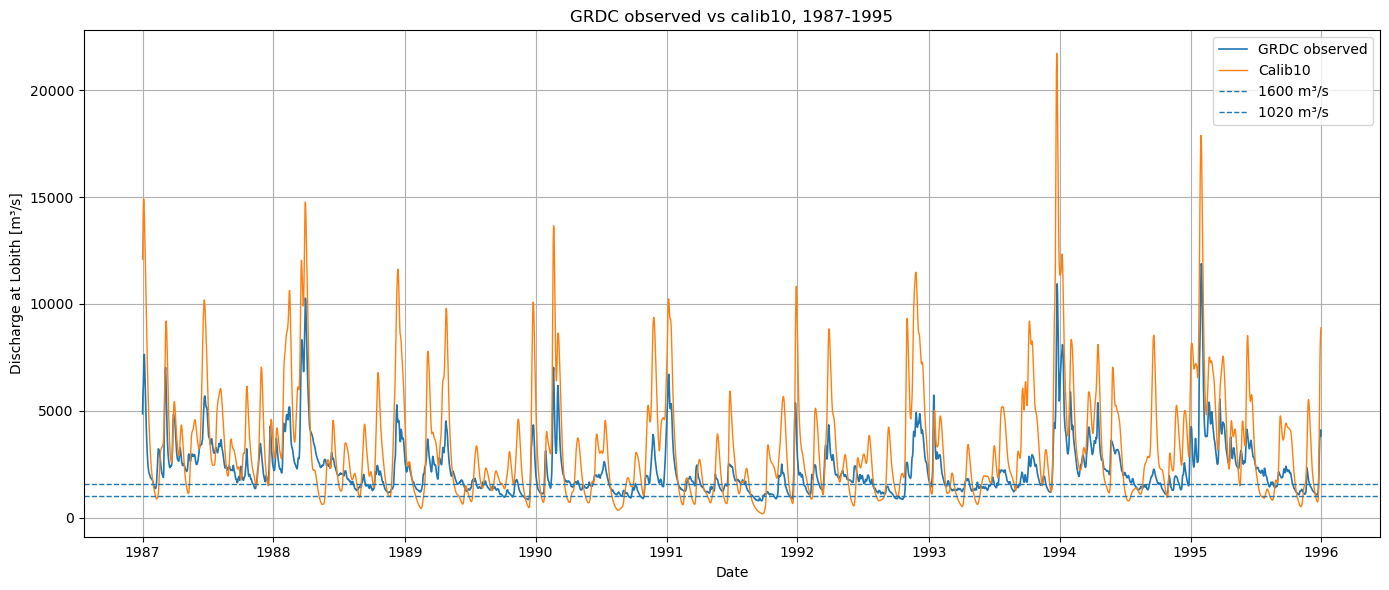

In [84]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_calib10["date"],
    comparison_calib10["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=1.2
)

plt.plot(
    comparison_calib10["date"],
    comparison_calib10["Q_model_m3s"],
    label="Calib10",
    linewidth=1.0
)

plt.axhline(1600, linestyle="--", linewidth=1, label="1600 m³/s")
plt.axhline(1020, linestyle="--", linewidth=1, label="1020 m³/s")

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("GRDC observed vs calib10, 1987-1995")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


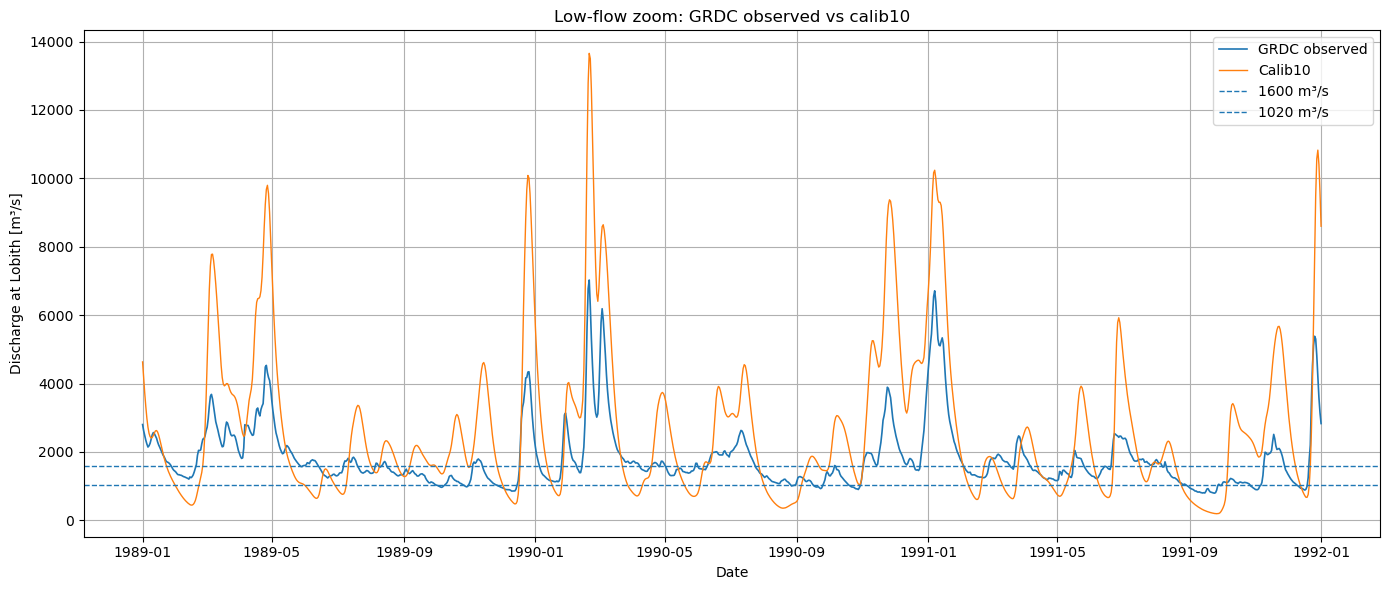

In [85]:
plot_start = "1989-01-01"
plot_end = "1992-01-01"

zoom = comparison_calib10[
    (comparison_calib10["date"] >= plot_start) &
    (comparison_calib10["date"] <= plot_end)
]

plt.figure(figsize=(14, 6))

plt.plot(
    zoom["date"],
    zoom["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=1.2
)

plt.plot(
    zoom["date"],
    zoom["Q_model_m3s"],
    label="Calib10",
    linewidth=1.0
)

plt.axhline(1600, linestyle="--", linewidth=1, label="1600 m³/s")
plt.axhline(1020, linestyle="--", linewidth=1, label="1020 m³/s")

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("Low-flow zoom: GRDC observed vs calib10")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [86]:
plot_compare = comparison_basis_full[["date", "Q_grdc_m3s", "Q_model_m3s"]].copy()
plot_compare = plot_compare.rename(columns={"Q_model_m3s": "Q_basis_m3s"})

calib10_temp = model_calib10[["date", "Q_model_m3s"]].copy()
calib10_temp = calib10_temp.rename(columns={"Q_model_m3s": "Q_calib10_m3s"})

plot_compare = pd.merge(
    plot_compare,
    calib10_temp,
    on="date",
    how="inner"
)

plot_compare.head()

,date,Q_grdc_m3s,Q_basis_m3s,Q_calib10_m3s
0,1987-01-01,4865.0,13869.678711,12101.763672
1,1987-01-02,5756.0,15741.568359,13396.190430
2,1987-01-03,6160.0,16061.675781,14481.406250
3,1987-01-04,6973.0,15124.300781,14916.130859
4,1987-01-05,7579.0,13978.630859,14704.667969


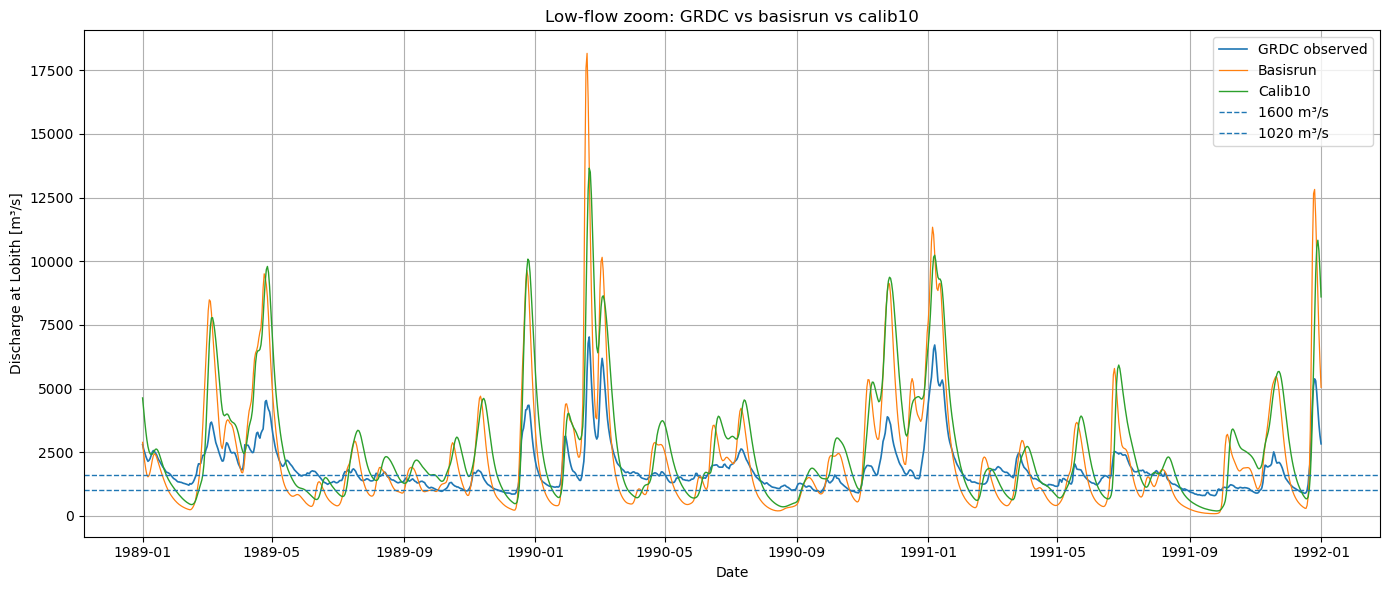

In [87]:
zoom = plot_compare[
    (plot_compare["date"] >= plot_start) &
    (plot_compare["date"] <= plot_end)
]

plt.figure(figsize=(14, 6))

plt.plot(zoom["date"], zoom["Q_grdc_m3s"], label="GRDC observed", linewidth=1.2)
plt.plot(zoom["date"], zoom["Q_basis_m3s"], label="Basisrun", linewidth=0.9)
plt.plot(zoom["date"], zoom["Q_calib10_m3s"], label="Calib10", linewidth=1.0)

plt.axhline(1600, linestyle="--", linewidth=1, label="1600 m³/s")
plt.axhline(1020, linestyle="--", linewidth=1, label="1020 m³/s")

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("Low-flow zoom: GRDC vs basisrun vs calib10")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [88]:
# FDC maken voor basis, calib4, calib8 en calib10

plot_data = comparison_basis_full[["date", "Q_grdc_m3s", "Q_model_m3s"]].copy()
plot_data = plot_data.rename(columns={"Q_model_m3s": "Q_basis_m3s"})

calib4_temp = model_calib4[["date", "Q_model_m3s"]].rename(columns={"Q_model_m3s": "Q_calib4_m3s"})
calib8_temp = model_calib8[["date", "Q_model_m3s"]].rename(columns={"Q_model_m3s": "Q_calib8_m3s"})
calib10_temp = model_calib10[["date", "Q_model_m3s"]].rename(columns={"Q_model_m3s": "Q_calib10_m3s"})

plot_data = pd.merge(plot_data, calib4_temp, on="date", how="inner")
plot_data = pd.merge(plot_data, calib8_temp, on="date", how="inner")
plot_data = pd.merge(plot_data, calib10_temp, on="date", how="inner")

In [89]:
fdc = pd.DataFrame()

fdc["GRDC"] = np.sort(plot_data["Q_grdc_m3s"].values)[::-1]
fdc["Basis"] = np.sort(plot_data["Q_basis_m3s"].values)[::-1]
fdc["Calib4"] = np.sort(plot_data["Q_calib4_m3s"].values)[::-1]
fdc["Calib8"] = np.sort(plot_data["Q_calib8_m3s"].values)[::-1]
fdc["Calib10"] = np.sort(plot_data["Q_calib10_m3s"].values)[::-1]

fdc["exceedance"] = np.arange(1, len(fdc) + 1) / (len(fdc) + 1) * 100

In [1]:
plt.figure(figsize=(10, 6))

plt.plot(fdc["exceedance"], fdc["GRDC"], label="GRDC", linewidth=1.3)
plt.plot(fdc["exceedance"], fdc["Basis"], label="Basis", linewidth=0.9)
plt.plot(fdc["exceedance"], fdc["Calib4"], label="Calib4", linewidth=1.0)
plt.plot(fdc["exceedance"], fdc["Calib8"], label="Calib8", linewidth=1.0)
plt.plot(fdc["exceedance"], fdc["Calib10"], label="Calib10", linewidth=1.0)

plt.axhline(1600, linestyle="--", linewidth=1, label="1600 m³/s")
plt.axhline(1020, linestyle="--", linewidth=1, label="1020 m³/s")

plt.ylim(0, 4000)

plt.xlabel("Overschreidingskans [%]")
plt.ylabel("Afvoer bij Lobith [m³/s]")
plt.title("Flow duration curve: kalibraties")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [91]:
config_file = list(run_dir.rglob("*.ini"))[0]

text = Path(config_file).read_text()

zoekwoorden = [
    "FirstZoneCapacity",
    "FirstZoneKsatVer",
    "FirstZoneMinCapacity",
    "InfiltCapSoil",
    "InfiltCapPath",
    "RootingDepth",
    "MaxCanopyStorage",
    "CanopyGapFraction",
    "N_River",
    "N"
]

for woord in zoekwoorden:
    print("\n---", woord, "---")
    for line in text.splitlines():
        if woord in line:
            print(line)


--- FirstZoneCapacity ---

--- FirstZoneKsatVer ---

--- FirstZoneMinCapacity ---

--- InfiltCapSoil ---

--- InfiltCapPath ---

--- RootingDepth ---
# RootingDepth=monthlyclim/ROOT,monthyclim,100,1
#RootingDepth=monthlyclim/ROOT,monthlyclim,75,1

--- MaxCanopyStorage ---

--- CanopyGapFraction ---

--- N_River ---

--- N ---
# - name - Name of the parameter (internal variable)
# - stack - Name of the mapstack (representation on disk or in mem) relative to case
#netcdf_format=NETCDF3_CLASSIC


In [92]:
static_files = list(run_dir.rglob("*"))

for file in static_files:
    name = file.name.lower()
    if (
        "firstzone" in name
        or "infilt" in name
        or "rooting" in name
        or "capacity" in name
        or "ksat" in name
    ):
        print(file)

/home/niels/BEP-Niels/temp_runs/calib10_PET_x0p90_CanopyGap_x1p25_NRiver_x2p00_N_x1p25/intbl/FirstZoneCapacity.tbl
/home/niels/BEP-Niels/temp_runs/calib10_PET_x0p90_CanopyGap_x1p25_NRiver_x2p00_N_x1p25/intbl/FirstZoneKsatVer.tbl
/home/niels/BEP-Niels/temp_runs/calib10_PET_x0p90_CanopyGap_x1p25_NRiver_x2p00_N_x1p25/intbl/FirstZoneMinCapacity.tbl
/home/niels/BEP-Niels/temp_runs/calib10_PET_x0p90_CanopyGap_x1p25_NRiver_x2p00_N_x1p25/intbl/InfiltCapPath.tbl
/home/niels/BEP-Niels/temp_runs/calib10_PET_x0p90_CanopyGap_x1p25_NRiver_x2p00_N_x1p25/intbl/InfiltCapSoil.tbl
/home/niels/BEP-Niels/temp_runs/calib10_PET_x0p90_CanopyGap_x1p25_NRiver_x2p00_N_x1p25/intbl/RootingDepth.tbl
/home/niels/BEP-Niels/temp_runs/calib10_PET_x0p90_CanopyGap_x1p25_NRiver_x2p00_N_x1p25/run_default/outsum/RootingDepth.map
/home/niels/BEP-Niels/temp_runs/calib10_PET_x0p90_CanopyGap_x1p25_NRiver_x2p00_N_x1p25/run_default/outsum/InfiltCapSoil.map
/home/niels/BEP-Niels/temp_runs/calib10_PET_x0p90_CanopyGap_x1p25_NRiver_x